In [2]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import os
import torch
from tqdm import tqdm
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [3]:
# ===== PATH SETUP =========

PROJECT_ROOT = "/content/drive/MyDrive/cassava_leaf_disease_classification"
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data/processed")
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")

# Ensure the output directory exists
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)


train_csv = os.path.join(PROCESSED_DATA_DIR, "train_split.csv")
val_csv = os.path.join(PROCESSED_DATA_DIR, "val_split.csv")
test_csv = os.path.join(PROCESSED_DATA_DIR, "test_split.csv")

In [4]:
# Label mapping for clean readability on the chart
label_map = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mite (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

In [5]:
# ======== TRANSFORMATION PIPELINE =========



class CassavaDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        """
        Custom Dataset for Cassava Leaf Disease Classification.
        """
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = int(row['label'])

        # Load image via PIL and convert to RGB
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


def get_data_loaders(project_root, batch_size=32):
    """
    Initializes transforms, datasets, and dataloaders for train, val, and test splits.
    Returns:
        train_loader, val_loader, test_loader, train_dataset
    """
    processed_data_dir = os.path.join(project_root, "data/processed")

    train_csv = os.path.join(processed_data_dir, "train_split.csv")
    val_csv = os.path.join(processed_data_dir, "val_split.csv")
    test_csv = os.path.join(processed_data_dir, "test_split.csv")

    # ImageNet Normalization Constants
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    # Baseline Transforms (Unaugmented for first trial)
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    # Instantiate Datasets
    train_dataset = CassavaDataset(csv_path=train_csv, transform=train_transforms)
    val_dataset = CassavaDataset(csv_path=val_csv, transform=val_test_transforms)
    test_dataset = CassavaDataset(test_csv, transform=val_test_transforms)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print("Data loaders initialized successfully!")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

    return train_loader, val_loader, test_loader, train_dataset

In [ ]:
# Use Transformation Pipeline

train_loader, val_loader, test_loader, train_dataset = get_data_loaders(PROJECT_ROOT, batch_size=32)

Data loaders initialized successfully!
Train batches: 469 | Val batches: 101 | Test batches: 101


In [ ]:
# Fetch a single batch from the train_loader
images, labels = next(iter(train_loader))

print(f"Batch image tensor shape: {images.shape}")
print(f"Batch label tensor shape: {labels.shape}")

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch label tensor shape: torch.Size([32])


# **TRAINING MODEL CELLS**

In [ ]:
# ======= DEVICE SETUP (CUDA IF AVAILABLE) =======

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

Using device: cuda
GPU Device Name: Tesla T4
VRAM Allocated: 0.00 MB


In [ ]:
# ======= CALCULATE CLASS WEIGHTS FOR LOSS FUNCTION =======


# Extract all labels from your train_dataset dataframe
train_labels = train_dataset.df['label'].values

# Compute inverse frequency class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert weights to a PyTorch tensor and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("\nComputed Class Weights (Inverse Frequencies):")
label_map = {
    0: "CBB",
    1: "CBSD",
    2: "CGM",
    3: "CMD",
    4: "Healthy"
}
for idx, weight in enumerate(class_weights_tensor):
    print(f"Class {idx} ({label_map[idx]}): {weight.item():.4f}")


Computed Class Weights (Inverse Frequencies):
Class 0 (CBB): 3.9361
Class 1 (CBSD): 1.9552
Class 2 (CGM): 1.7937
Class 3 (CMD): 0.3252
Class 4 (Healthy): 1.6604


In [ ]:
# ======= INITIALIZE PRETRAINED MOBILENET_V2 =======


# Load MobileNetV2 with default pretrained ImageNet weights
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Modify the classifier head for our 5 cassava classes
num_classes = 5
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move model to CUDA/CPU device
model = model.to(device)

print("\nMobileNetV2 successfully initialized and moved to device!")
print(f"Modified classifier head: {model.classifier[1]}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 55.6MB/s]



MobileNetV2 successfully initialized and moved to device!
Modified classifier head: Linear(in_features=1280, out_features=5, bias=True)


In [ ]:
# =========== Trainable Parameter ======

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 2,230,277
Trainable Parameters: 2,230,277


In [ ]:
# Instantiate Weighted Cross-Entropy Loss

# This directly addresses our 61.5% vs 5.1% class imbalance problem
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)



# Instantiate Optimizer

# Using Adam with a fine-tuning learning rate of 1e-4
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function and optimizer successfully configured!")
print(f"Loss Function: {criterion}")
print(f"Optimizer: Adam (Learning Rate: {learning_rate})")

Loss function and optimizer successfully configured!
Loss Function: CrossEntropyLoss()
Optimizer: Adam (Learning Rate: 0.0001)


In [ ]:
# ======= TRAINING CONFIGURATION =======
NUM_EPOCHS = 5
best_val_f1 = 0.0

# Ensure output model directory exists
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "output/models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(MODEL_SAVE_DIR, "best_mobilenetv2_baseline.pth")

print(f"Starting training for {NUM_EPOCHS} epochs on device: {device}\n")

Starting training for 5 epochs on device: cuda



In [ ]:
for epoch in range(NUM_EPOCHS):
    print(f"================ Epoch [{epoch+1}/{NUM_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for images, labels in train_loop:
        # Move batch tensors to GPU/CPU device
        images = images.to(device)
        labels = labels.to(device)

        # Zero out gradients from previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)

        # Calculate loss using our weighted cross-entropy criterion
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Track training loss
        train_loss += loss.item() * images.size(0)

        # Collect predictions and ground truth for metric evaluation
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

        # Update progress bar suffix with current batch loss
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
    with torch.no_grad(): # Disable gradient calculation during validation to save memory
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    # Save the checkpoint if validation Macro-F1 improves
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

print("Training complete!")

================ Epoch [1/5] ================


Validation Epoch 1: 100%|██████████| 101/101 [11:33<00:00,  6.87s/it, loss=0.5213]



Results - Epoch 1:
  [Train] Loss: 1.0564 | Acc: 0.6738 | Macro-F1: 0.5378
  [Val]   Loss: 0.8231 | Acc: 0.7424 | Macro-F1: 0.6305
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.6305) <<<

================ Epoch [2/5] ================


Validation Epoch 2: 100%|██████████| 101/101 [00:29<00:00,  3.45it/s, loss=0.2605]



Results - Epoch 2:
  [Train] Loss: 0.6717 | Acc: 0.8021 | Macro-F1: 0.7062
  [Val]   Loss: 0.7745 | Acc: 0.7931 | Macro-F1: 0.6722
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.6722) <<<

================ Epoch [3/5] ================


...


Results - Epoch 3:
  [Train] Loss: 0.4616 | Acc: 0.8584 | Macro-F1: 0.7938
  [Val]   Loss: 0.8822 | Acc: 0.7645 | Macro-F1: 0.6452
--------------------------------------------------
================ Epoch [4/5] ================


Validation Epoch 4: 100%|██████████| 101/101 [00:29<00:00,  3.38it/s, loss=0.1280]



Results - Epoch 4:
  [Train] Loss: 0.2896 | Acc: 0.9049 | Macro-F1: 0.8666
  [Val]   Loss: 1.0021 | Acc: 0.7664 | Macro-F1: 0.6473
--------------------------------------------------
================ Epoch [5/5] ================


Validation Epoch 5: 100%|██████████| 101/101 [00:28<00:00,  3.51it/s, loss=0.1088]


Results - Epoch 5:
  [Train] Loss: 0.1604 | Acc: 0.9419 | Macro-F1: 0.9240
  [Val]   Loss: 1.0552 | Acc: 0.7754 | Macro-F1: 0.6642
--------------------------------------------------
Training complete!


In [ ]:
# ======= CONTINUE TRAINING FOR 5 MORE EPOCHS =======
ADDITIONAL_EPOCHS = 5

print(f"Resuming training for {ADDITIONAL_EPOCHS} more epochs...\n")

for epoch in range(NUM_EPOCHS, NUM_EPOCHS + ADDITIONAL_EPOCHS):
    print(f"================ Epoch [{epoch+1}/{NUM_EPOCHS + ADDITIONAL_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for images, labels in train_loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
    with torch.no_grad():
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

# Update total epoch tracker
NUM_EPOCHS += ADDITIONAL_EPOCHS
print("Additional training complete!")

Resuming training for 5 more epochs...

================ Epoch [6/10] ================


Validation Epoch 6: 100%|██████████| 101/101 [00:29<00:00,  3.38it/s, loss=0.0827]



Results - Epoch 6:
  [Train] Loss: 0.1166 | Acc: 0.9533 | Macro-F1: 0.9410
  [Val]   Loss: 1.2120 | Acc: 0.8031 | Macro-F1: 0.6768
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.6768) <<<

================ Epoch [7/10] ================


Validation Epoch 7: 100%|██████████| 101/101 [00:29<00:00,  3.45it/s, loss=0.0713]



Results - Epoch 7:
  [Train] Loss: 0.0850 | Acc: 0.9676 | Macro-F1: 0.9574
  [Val]   Loss: 1.2872 | Acc: 0.8003 | Macro-F1: 0.6688
--------------------------------------------------
================ Epoch [8/10] ================


...


Results - Epoch 8:
  [Train] Loss: 0.0702 | Acc: 0.9716 | Macro-F1: 0.9625
  [Val]   Loss: 1.4178 | Acc: 0.8100 | Macro-F1: 0.6743
--------------------------------------------------
================ Epoch [9/10] ================


Validation Epoch 9: 100%|██████████| 101/101 [00:29<00:00,  3.45it/s, loss=0.0485]



Results - Epoch 9:
  [Train] Loss: 0.0728 | Acc: 0.9731 | Macro-F1: 0.9648
  [Val]   Loss: 1.4904 | Acc: 0.8121 | Macro-F1: 0.6712
--------------------------------------------------
================ Epoch [10/10] ================


Validation Epoch 10: 100%|██████████| 101/101 [00:29<00:00,  3.47it/s, loss=0.0214]


Results - Epoch 10:
  [Train] Loss: 0.0508 | Acc: 0.9798 | Macro-F1: 0.9730
  [Val]   Loss: 1.4185 | Acc: 0.8081 | Macro-F1: 0.6907
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.6907) <<<

Additional training complete!


In [ ]:
# ======= 1. LOAD SAVED BEST MODEL =======


PROJECT_ROOT = "/content/drive/MyDrive/cassava_leaf_disease_classification"
best_model_path = os.path.join(PROJECT_ROOT, "output/models/best_mobilenetv2_baseline.pth")

# Initialize architecture
model_eval = mobilenet_v2(weights=None)
num_classes = 5
in_features = model_eval.classifier[1].in_features
model_eval.classifier[1] = nn.Linear(in_features, num_classes)

# Load the saved state dictionary
model_eval.load_state_dict(torch.load(best_model_path, map_location=device))
model_eval = model_eval.to(device)
model_eval.eval()

print("Best baseline model successfully loaded from Drive for testing!\n")

Best baseline model successfully loaded from Drive for testing!



In [ ]:
# ======= 2. RUN EVALUATION ON TEST LOADER (WITH TQDM) =======
test_preds = []
test_targets = []

print("Running evaluation on the test set...")
test_loop = tqdm(test_loader, desc="Evaluating Test Set")

with torch.no_grad():
    for images, labels in test_loop:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_eval(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

# ======= 3. COMPUTE METRICS =======
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print(f"\n================ TEST RESULTS ================")
print(f"Overall Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Test Macro-F1 Score:   {test_f1:.4f}")
print("==============================================\n")

# Detailed per-class breakdown
label_names = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]
print("Detailed Classification Report:")
print(classification_report(test_targets, test_preds, target_names=label_names, zero_division=0))

Running evaluation on the test set...


Evaluating Test Set: 100%|██████████| 101/101 [11:05<00:00,  6.59s/it]


================ TEST RESULTS ================
Overall Test Accuracy: 0.7991 (79.91%)
Test Macro-F1 Score:   0.6710

Detailed Classification Report:
              precision    recall  f1-score   support

         CBB       0.50      0.48      0.49       163
        CBSD       0.64      0.69      0.66       329
         CGM       0.64      0.72      0.68       358
         CMD       0.94      0.89      0.91      1974
     Healthy       0.58      0.64      0.61       386

    accuracy                           0.80      3210
   macro avg       0.66      0.68      0.67      3210
weighted avg       0.81      0.80      0.80      3210



Confusion matrix plot successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/confusion_matrix_baseline.png


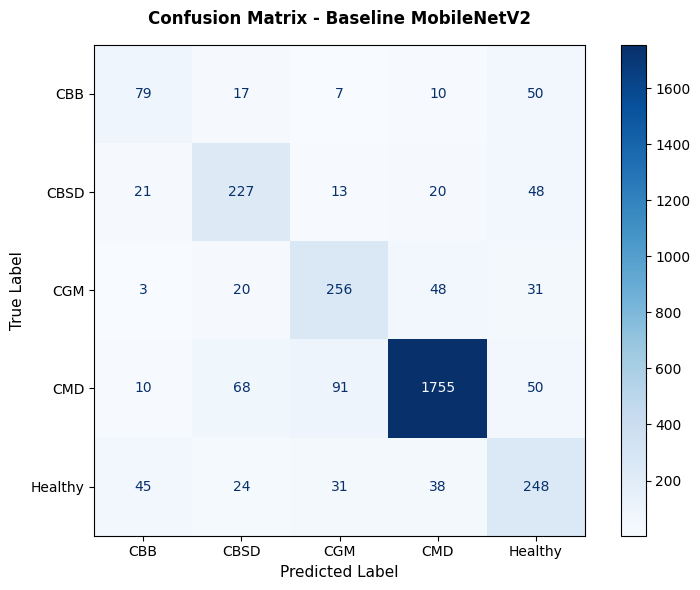

In [ ]:
# ======= PLOT CONFUSION MATRIX =======



label_names = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca(), colorbar=True)

plt.title('Confusion Matrix - Baseline MobileNetV2', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.grid(False) # Turn off grid lines for clean display
plt.tight_layout()

# Save confusion matrix plot to your image output directory
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
cm_save_path = os.path.join(OUTPUT_IMG_DIR, "confusion_matrix_baseline.png")

plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix plot successfully saved to: {cm_save_path}")

# **INTRODUCING AUGMENTATION**

In [6]:
# ========== TARGETED AUGMENTATION =======



class CassavaDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        """
        Custom Dataset for Cassava Leaf Disease Classification.
        """
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = int(row['label'])

        # Load image via PIL and convert to RGB
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


def get_data_loaders(project_root, batch_size=32):
    """
    Initializes transforms, datasets, and dataloaders for train, val, and test splits.
    Includes targeted data augmentations for the training set.
    """
    processed_data_dir = os.path.join(project_root, "data/processed")

    train_csv = os.path.join(processed_data_dir, "train_split.csv")
    val_csv = os.path.join(processed_data_dir, "val_split.csv")
    test_csv = os.path.join(processed_data_dir, "test_split.csv")

    # ImageNet Normalization Constants
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    # ======= TARGETED AUGMENTED TRANSFORMS (TRAIN SET) =======
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Scale variation & focus
        transforms.RandomHorizontalFlip(p=0.5),             # Natural leaf orientation
        transforms.RandomVerticalFlip(p=0.5),               # Natural leaf orientation
        transforms.RandomRotation(degrees=20),              # Angle and tilt variance
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05                                        # Strict hue constraint to protect biological leaf color
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    # ======= UNAUGMENTED TRANSFORMS (VAL & TEST SETS) =======
    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    # Instantiate Datasets
    train_dataset = CassavaDataset(csv_path=train_csv, transform=train_transforms)
    val_dataset = CassavaDataset(csv_path=val_csv, transform=val_test_transforms)
    test_dataset = CassavaDataset(test_csv, transform=val_test_transforms)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print("Data loaders with targeted augmentations initialized successfully!")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

    return train_loader, val_loader, test_loader, train_dataset

In [7]:
# Use Transformation Pipeline

train_loader, val_loader, test_loader, train_dataset = get_data_loaders(PROJECT_ROOT, batch_size=32)

Data loaders with targeted augmentations initialized successfully!
Train batches: 469 | Val batches: 101 | Test batches: 101


In [8]:
# Fetch a single batch from the train_loader
images, labels = next(iter(train_loader))

print(f"Batch image tensor shape: {images.shape}")
print(f"Batch label tensor shape: {labels.shape}")

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch label tensor shape: torch.Size([32])


In [9]:
# ======= DEVICE SETUP (CUDA IF AVAILABLE) =======

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

Using device: cuda
GPU Device Name: Tesla T4
VRAM Allocated: 0.00 MB


In [10]:
# ======= CALCULATE CLASS WEIGHTS FOR LOSS FUNCTION =======


# Extract all labels from your train_dataset dataframe
train_labels = train_dataset.df['label'].values

# Compute inverse frequency class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert weights to a PyTorch tensor and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("\nComputed Class Weights (Inverse Frequencies):")
label_map = {
    0: "CBB",
    1: "CBSD",
    2: "CGM",
    3: "CMD",
    4: "Healthy"
}
for idx, weight in enumerate(class_weights_tensor):
    print(f"Class {idx} ({label_map[idx]}): {weight.item():.4f}")


Computed Class Weights (Inverse Frequencies):
Class 0 (CBB): 3.9361
Class 1 (CBSD): 1.9552
Class 2 (CGM): 1.7937
Class 3 (CMD): 0.3252
Class 4 (Healthy): 1.6604


In [11]:
# ======= INITIALIZE PRETRAINED MOBILENET_V2 =======


# Load MobileNetV2 with default pretrained ImageNet weights
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Modify the classifier head for our 5 cassava classes
num_classes = 5
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move model to CUDA/CPU device
model = model.to(device)

print("\nMobileNetV2 successfully initialized and moved to device!")
print(f"Modified classifier head: {model.classifier[1]}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s] 


MobileNetV2 successfully initialized and moved to device!
Modified classifier head: Linear(in_features=1280, out_features=5, bias=True)


In [12]:
# Instantiate Weighted Cross-Entropy Loss

# This directly addresses our 61.5% vs 5.1% class imbalance problem
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)



# Instantiate Optimizer

# Using Adam with a fine-tuning learning rate of 1e-4
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function and optimizer successfully configured!")
print(f"Loss Function: {criterion}")
print(f"Optimizer: Adam (Learning Rate: {learning_rate})")

Loss function and optimizer successfully configured!
Loss Function: CrossEntropyLoss()
Optimizer: Adam (Learning Rate: 0.0001)


In [13]:
# ======= TRAINING CONFIGURATION =======
NUM_EPOCHS = 10
best_val_f1 = 0.0

# Ensure output model directory exists
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "output/models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(MODEL_SAVE_DIR, "best_mobilenetv2_augmented.pth")

print(f"Starting training for {NUM_EPOCHS} epochs on device: {device}\n")

Starting training for 10 epochs on device: cuda



In [ ]:
# ======= INITIALIZE HISTORY DICTIONARY =======
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

for epoch in range(NUM_EPOCHS):
    print(f"================ Epoch [{epoch+1}/{NUM_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for images, labels in train_loop:
        # Move batch tensors to GPU/CPU device
        images = images.to(device)
        labels = labels.to(device)

        # Zero out gradients from previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)

        # Calculate loss using our weighted cross-entropy criterion
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Track training loss
        train_loss += loss.item() * images.size(0)

        # Collect predictions and ground truth for metric evaluation
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

        # Update progress bar suffix with current batch loss
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
    with torch.no_grad(): # Disable gradient calculation during validation to save memory
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. SAVE METRICS TO HISTORY =================
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['train_f1'].append(epoch_train_f1)
    history['val_f1'].append(epoch_val_f1)

    # ================= 4. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    # Save the checkpoint if validation Macro-F1 improves
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

print("Training complete!")

================ Epoch [1/10] ================


Validation Epoch 1: 100%|██████████| 101/101 [00:29<00:00,  3.44it/s, loss=1.1140]



Results - Epoch 1:
  [Train] Loss: 1.1293 | Acc: 0.6372 | Macro-F1: 0.5013
  [Val]   Loss: 0.9735 | Acc: 0.6277 | Macro-F1: 0.5410
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.5410) <<<

================ Epoch [2/10] ================


Validation Epoch 2: 100%|██████████| 101/101 [00:29<00:00,  3.47it/s, loss=0.5415]



Results - Epoch 2:
  [Train] Loss: 0.8236 | Acc: 0.7465 | Macro-F1: 0.6374
  [Val]   Loss: 0.8097 | Acc: 0.7445 | Macro-F1: 0.6289
  >>> Saved New Best Model Checkpoint (Val Macro-F1: 0.6289) <<<

================ Epoch [3/10] ================


...


Results - Epoch 8:
  [Train] Loss: 0.5629 | Acc: 0.8278 | Macro-F1: 0.7465
  [Val]   Loss: 0.7544 | Acc: 0.7925 | Macro-F1: 0.6832
--------------------------------------------------
================ Epoch [9/10] ================


Validation Epoch 9: 100%|██████████| 101/101 [00:29<00:00,  3.46it/s, loss=0.3401]



Results - Epoch 9:
  [Train] Loss: 0.5155 | Acc: 0.8427 | Macro-F1: 0.7673
  [Val]   Loss: 0.7881 | Acc: 0.8000 | Macro-F1: 0.6838
--------------------------------------------------
================ Epoch [10/10] ================


Validation Epoch 10: 100%|██████████| 101/101 [00:29<00:00,  3.40it/s, loss=0.4092]


Results - Epoch 10:
  [Train] Loss: 0.5121 | Acc: 0.8369 | Macro-F1: 0.7610
  [Val]   Loss: 0.7695 | Acc: 0.8044 | Macro-F1: 0.6931
--------------------------------------------------
Training complete!


In [ ]:
# ======= CONTINUE TRAINING FOR 10 MORE EPOCHS =======
ADDITIONAL_EPOCHS = 10
start_epoch = NUM_EPOCHS
NUM_EPOCHS += ADDITIONAL_EPOCHS

print(f"Resuming augmented training from epoch {start_epoch + 1} for {ADDITIONAL_EPOCHS} more epochs...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"================ Epoch [{epoch+1}/{NUM_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for images, labels in train_loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
    with torch.no_grad():
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. APPEND TO EXISTING HISTORY =================
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['train_f1'].append(epoch_train_f1)
    history['val_f1'].append(epoch_val_f1)

    # ================= 4. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    # Save checkpoint if validation Macro-F1 improves
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

print("Additional training complete!")

Resuming augmented training from epoch 11 for 10 more epochs...

================ Epoch [11/20] ================


Validation Epoch 11: 100%|██████████| 101/101 [00:29<00:00,  3.41it/s, loss=0.3589]



Results - Epoch 11:
  [Train] Loss: 0.4705 | Acc: 0.8510 | Macro-F1: 0.7848
  [Val]   Loss: 0.8131 | Acc: 0.7894 | Macro-F1: 0.6733
--------------------------------------------------
================ Epoch [12/20] ================


Validation Epoch 12: 100%|██████████| 101/101 [00:31<00:00,  3.23it/s, loss=0.4160]



Results - Epoch 12:
  [Train] Loss: 0.4587 | Acc: 0.8567 | Macro-F1: 0.7914
  [Val]   Loss: 0.8275 | Acc: 0.8012 | Macro-F1: 0.6904
--------------------------------------------------
================ Epoch [13/20] ================


...


Results - Epoch 18:
  [Train] Loss: 0.3427 | Acc: 0.8790 | Macro-F1: 0.8332
  [Val]   Loss: 0.9486 | Acc: 0.7931 | Macro-F1: 0.6841
--------------------------------------------------
================ Epoch [19/20] ================


Validation Epoch 19: 100%|██████████| 101/101 [00:28<00:00,  3.52it/s, loss=0.1218]



Results - Epoch 19:
  [Train] Loss: 0.3234 | Acc: 0.8842 | Macro-F1: 0.8413
  [Val]   Loss: 0.9450 | Acc: 0.8187 | Macro-F1: 0.7046
--------------------------------------------------
================ Epoch [20/20] ================


Validation Epoch 20: 100%|██████████| 101/101 [00:29<00:00,  3.47it/s, loss=0.3252]


Results - Epoch 20:
  [Train] Loss: 0.3244 | Acc: 0.8863 | Macro-F1: 0.8427
  [Val]   Loss: 0.8761 | Acc: 0.8037 | Macro-F1: 0.6955
--------------------------------------------------
Additional training complete!


In [ ]:
# ======= CONTINUE TRAINING FOR 10 MORE EPOCHS =======
ADDITIONAL_EPOCHS = 10
start_epoch = NUM_EPOCHS
NUM_EPOCHS += ADDITIONAL_EPOCHS

print(f"Resuming augmented training from epoch {start_epoch + 1} for {ADDITIONAL_EPOCHS} more epochs...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"================ Epoch [{epoch+1}/{NUM_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for images, labels in train_loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
    with torch.no_grad():
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. APPEND TO EXISTING HISTORY =================
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['train_f1'].append(epoch_train_f1)
    history['val_f1'].append(epoch_val_f1)

    # ================= 4. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    # Save checkpoint if validation Macro-F1 improves
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

print("Additional training complete!")

Resuming augmented training from epoch 21 for 10 more epochs...

================ Epoch [21/30] ================


Validation Epoch 21: 100%|██████████| 101/101 [00:29<00:00,  3.38it/s, loss=0.3424]



Results - Epoch 21:
  [Train] Loss: 0.2928 | Acc: 0.8947 | Macro-F1: 0.8563
  [Val]   Loss: 0.9605 | Acc: 0.8012 | Macro-F1: 0.6804
--------------------------------------------------
================ Epoch [22/30] ================


Validation Epoch 22: 100%|██████████| 101/101 [00:29<00:00,  3.42it/s, loss=0.1798]



Results - Epoch 22:
  [Train] Loss: 0.2935 | Acc: 0.8934 | Macro-F1: 0.8523
  [Val]   Loss: 1.0002 | Acc: 0.8103 | Macro-F1: 0.6939
--------------------------------------------------
================ Epoch [23/30] ================


Training Epoch 23:  26%|██▋       | 124/469 [01:00<02:07,  2.70it/s, loss=0.4546]

In [ ]:
# ======= 1. LOAD SAVED BEST MODEL =======


PROJECT_ROOT = "/content/drive/MyDrive/cassava_leaf_disease_classification"
best_model_path = os.path.join(PROJECT_ROOT, "output/models/best_mobilenetv2_augmented.pth")

# Initialize architecture
model_eval = mobilenet_v2(weights=None)
num_classes = 5
in_features = model_eval.classifier[1].in_features
model_eval.classifier[1] = nn.Linear(in_features, num_classes)

# Load the saved state dictionary
model_eval.load_state_dict(torch.load(best_model_path, map_location=device))
model_eval = model_eval.to(device)
model_eval.eval()

print("Best baseline model successfully loaded from Drive for testing!\n")

Best baseline model successfully loaded from Drive for testing!



In [ ]:
# ======= 2. RUN EVALUATION ON TEST LOADER (WITH TQDM) =======
test_preds = []
test_targets = []

print("Running evaluation on the test set...")
test_loop = tqdm(test_loader, desc="Evaluating Test Set")

with torch.no_grad():
    for images, labels in test_loop:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_eval(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

# ======= 3. COMPUTE METRICS =======
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print(f"\n================ TEST RESULTS ================")
print(f"Overall Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Test Macro-F1 Score:   {test_f1:.4f}")
print("==============================================\n")

# Detailed per-class breakdown
label_names = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]
print("Detailed Classification Report:")
print(classification_report(test_targets, test_preds, target_names=label_names, zero_division=0))

Running evaluation on the test set...


Evaluating Test Set:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating Test Set: 100%|██████████| 101/101 [09:52<00:00,  5.86s/it]


================ TEST RESULTS ================
Overall Test Accuracy: 0.8234 (82.34%)
Test Macro-F1 Score:   0.7151

Detailed Classification Report:
              precision    recall  f1-score   support

         CBB       0.53      0.61      0.57       163
        CBSD       0.74      0.71      0.73       329
         CGM       0.72      0.74      0.73       358
         CMD       0.95      0.90      0.93      1974
     Healthy       0.57      0.70      0.63       386

    accuracy                           0.82      3210
   macro avg       0.70      0.73      0.72      3210
weighted avg       0.84      0.82      0.83      3210



Confusion matrix plot successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/confusion_matrix_augmented.png


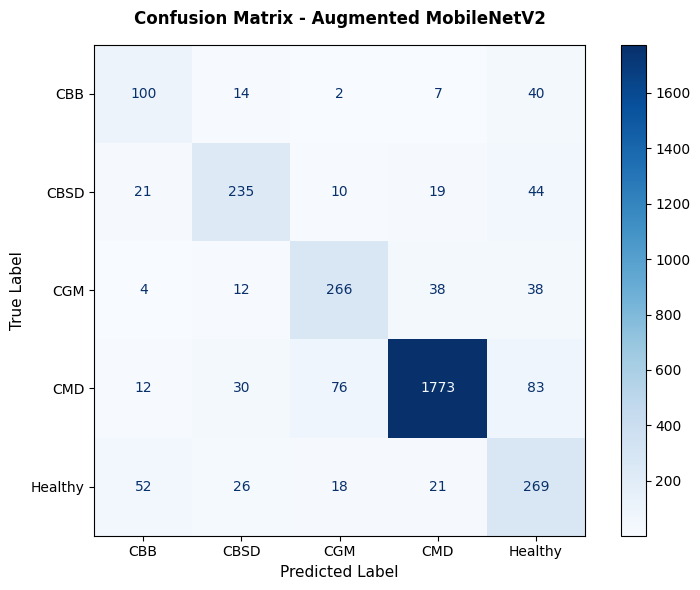

In [ ]:
# ======= PLOT CONFUSION MATRIX =======



label_names = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca(), colorbar=True)

plt.title('Confusion Matrix - Augmented MobileNetV2', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.grid(False) # Turn off grid lines for clean display
plt.tight_layout()

# Save confusion matrix plot to your image output directory
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
cm_save_path = os.path.join(OUTPUT_IMG_DIR, "confusion_matrix_augmented.png")

plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix plot successfully saved to: {cm_save_path}")

# **FINETUNNING MODEL FOR HIGHER ACCURACY**

In [14]:
# ======= CALCULATE CLASS WEIGHTS FOR LOSS FUNCTION =======


# Extract all labels from your train_dataset dataframe
train_labels = train_dataset.df['label'].values

# Compute inverse frequency class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert weights to a PyTorch tensor and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("\nComputed Class Weights (Inverse Frequencies):")
label_map = {
    0: "CBB",
    1: "CBSD",
    2: "CGM",
    3: "CMD",
    4: "Healthy"
}
for idx, weight in enumerate(class_weights_tensor):
    print(f"Class {idx} ({label_map[idx]}): {weight.item():.4f}")


Computed Class Weights (Inverse Frequencies):
Class 0 (CBB): 3.9361
Class 1 (CBSD): 1.9552
Class 2 (CGM): 1.7937
Class 3 (CMD): 0.3252
Class 4 (Healthy): 1.6604


In [15]:
# ======= INITIALIZE PRETRAINED MOBILENET_V2 =======


# Load MobileNetV2 with default pretrained ImageNet weights
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Modify the classifier head for our 5 cassava classes
num_classes = 5
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move model to CUDA/CPU device
model = model.to(device)

print("\nMobileNetV2 successfully initialized and moved to device!")
print(f"Modified classifier head: {model.classifier[1]}")


MobileNetV2 successfully initialized and moved to device!
Modified classifier head: Linear(in_features=1280, out_features=5, bias=True)


In [16]:
# ======= SELECTIVE UNFREEZING FOR FINE-TUNING =======



# MobileNetV2's feature extractor contains sequential blocks indexed 0 through 18.

# 1. Freeze all feature extraction blocks first
for param in model.features.parameters():
    param.requires_grad = False

# 2. Unfreeze only the final blocks (from block 14 to 18) for task-specific adaptation
for i, block in enumerate(model.features):
    if i >= 14:
        for param in block.parameters():
            param.requires_grad = True

# 3. Ensure the classifier head is fully trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# 4. Define a lower, safer fine-tuning learning rate
fine_tune_lr = 1e-5
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=fine_tune_lr
)

# This directly addresses our 61.5% vs 5.1% class imbalance problem
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Update model save path for this fine-tuned trial
best_model_path = os.path.join(MODEL_SAVE_DIR, "best_mobilenetv2_finetuned.pth")

print("MobileNetV2 successfully reconfigured for fine-tuning!")
print("  - Blocks 0-13: Frozen (Preserving ImageNet feature detectors)")
print("  - Blocks 14-18 & Classifier: Unfrozen (Adapting to Cassava diseases)")
print(f"  - Fine-Tuning Learning Rate: {fine_tune_lr}")
print(f"  - Checkpoint path updated to: {best_model_path}\n")

MobileNetV2 successfully reconfigured for fine-tuning!
  - Blocks 0-13: Frozen (Preserving ImageNet feature detectors)
  - Blocks 14-18 & Classifier: Unfrozen (Adapting to Cassava diseases)
  - Fine-Tuning Learning Rate: 1e-05
  - Checkpoint path updated to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/models/best_mobilenetv2_finetuned.pth



In [ ]:
# ======= FINE-TUNING CONFIGURATION =======
FINE_TUNE_EPOCHS = 15
best_val_f1 = 0.0  # Reset or keep your previous best to beat it

# Reset or initialize history dictionary for the fine-tuning run
history_finetune = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

print(f"Starting fine-tuning for {FINE_TUNE_EPOCHS} epochs on device: {device}\n")

for epoch in range(FINE_TUNE_EPOCHS):
    print(f"================ Fine-Tune Epoch [{epoch+1}/{FINE_TUNE_EPOCHS}] ================")

    # ================= 1. TRAINING PHASE =================
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    train_loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}")
    for images, labels in train_loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_targets, train_preds)
    epoch_train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # ================= 2. VALIDATION PHASE =================
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    val_loop = tqdm(val_loader, desc=f"Val Epoch {epoch+1}")
    with torch.no_grad():
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_targets, val_preds)
    epoch_val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    # ================= 3. SAVE TO HISTORY =================
    history_finetune['train_loss'].append(epoch_train_loss)
    history_finetune['val_loss'].append(epoch_val_loss)
    history_finetune['train_acc'].append(epoch_train_acc)
    history_finetune['val_acc'].append(epoch_val_acc)
    history_finetune['train_f1'].append(epoch_train_f1)
    history_finetune['val_f1'].append(epoch_val_f1)

    # ================= 4. EPOCH SUMMARY =================
    print(f"\nResults - Epoch {epoch+1}:")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Macro-F1: {epoch_train_f1:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Macro-F1: {epoch_val_f1:.4f}")

    # Save checkpoint if validation Macro-F1 improves
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  >>> Saved New Best Fine-Tuned Model Checkpoint (Val Macro-F1: {best_val_f1:.4f}) <<<\n")
    else:
        print("-" * 50)

print("Fine-tuning complete!")

Starting fine-tuning for 15 epochs on device: cuda

================ Fine-Tune Epoch [1/15] ================


Val Epoch 1: 100%|██████████| 101/101 [07:12<00:00,  4.28s/it, loss=1.5741]



Results - Epoch 1:
  [Train] Loss: 1.5637 | Acc: 0.4237 | Macro-F1: 0.2660
  [Val]   Loss: 1.5142 | Acc: 0.4826 | Macro-F1: 0.3535
  >>> Saved New Best Fine-Tuned Model Checkpoint (Val Macro-F1: 0.3535) <<<

================ Fine-Tune Epoch [2/15] ================


Val Epoch 2: 100%|██████████| 101/101 [00:36<00:00,  2.73it/s, loss=1.5203]



Results - Epoch 2:
  [Train] Loss: 1.4219 | Acc: 0.5862 | Macro-F1: 0.4146
  [Val]   Loss: 1.3829 | Acc: 0.5097 | Macro-F1: 0.4278
  >>> Saved New Best Fine-Tuned Model Checkpoint (Val Macro-F1: 0.4278) <<<

================ Fine-Tune Epoch [3/15] ================


...

Val Epoch 10: 100%|██████████| 101/101 [00:32<00:00,  3.14it/s, loss=1.1537]



Results - Epoch 10:
  [Train] Loss: 0.9507 | Acc: 0.6934 | Macro-F1: 0.5794
  [Val]   Loss: 0.9730 | Acc: 0.6252 | Macro-F1: 0.5443
--------------------------------------------------
================ Fine-Tune Epoch [11/15] ================


Val Epoch 11: 100%|██████████| 101/101 [00:31<00:00,  3.21it/s, loss=0.9779]



Results - Epoch 11:
  [Train] Loss: 0.9198 | Acc: 0.7053 | Macro-F1: 0.5935
  [Val]   Loss: 0.9501 | Acc: 0.6486 | Macro-F1: 0.5571
  >>> Saved New Best Fine-Tuned Model Checkpoint (Val Macro-F1: 0.5571) <<<

================ Fine-Tune Epoch [12/15] ================


Train Epoch 12:  28%|██▊       | 132/469 [01:07<02:13,  2.53it/s, loss=0.5483]

NameError: name 'history_finetune' is not defined

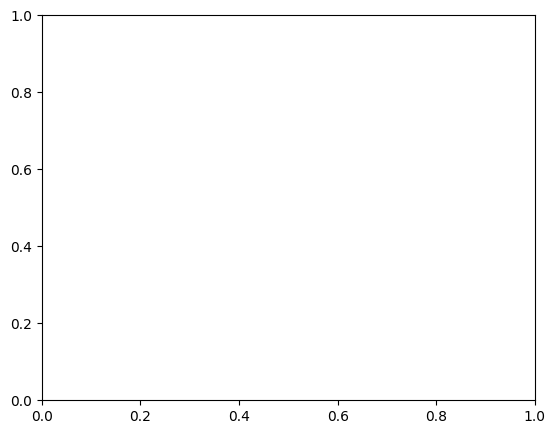

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history_finetune['train_loss'], label='Train Loss', marker='o', color='royalblue')
plt.plot(history_finetune['val_loss'], label='Val Loss', marker='o', color='darkorange')
plt.title('Fine-Tuning: Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history_finetune['train_acc'], label='Train Acc', marker='o', color='royalblue')
plt.plot(history_finetune['val_acc'], label='Val Acc', marker='o', color='darkorange')
plt.title('Fine-Tuning: Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
finetune_curve_path = os.path.join(PROJECT_ROOT, "output/image/finetuning_curves.png")
plt.savefig(finetune_curve_path, dpi=300, bbox_inches='tight')
print(f"Fine-tuning curves saved to: {finetune_curve_path}")
plt.show()